In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import random

# ==================== REPRODUCIBILITY SETTINGS ====================
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

import os
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
# ===================================================================

## Data Loading and Configuration

In [2]:
# Configuration
CAMPAIGN_NAME = 'Sentinel-2 Campaign'
bands_list = [11, 4, 3, 1]  # 4 bands selected
NUM_HARALICK_FEATURES = 13

# Haralick feature names
HARALICK_FEATURE_NAMES = [
    'ASM', 'Contrast', 'Correlation', 'Variance', 'IDM',
    'Sum_Average', 'Sum_Variance', 'Sum_Entropy', 'Entropy',
    'Diff_Variance', 'Diff_Entropy', 'IMC1', 'IMC2'
]

# Training file paths
train_file_path = [
    'data/train/sentinel_big_campaign_with_outliers_train.csv',
    'data/train/sentinel_big_campaign_percentile_by_task_train.csv',
    'data/train/sentinel_big_campaign_percentile_global_train.csv',
    'data/train/sentinel_big_campaign_tukey_train.csv',
    'data/train/sentinel_big_campaign_zscore_train.csv',
    'data/train/sentinel_big_campaign_mad_train.csv'
]

# Index for Tukey approach
IDX_WITH_OUTLIERS = 0
IDX_TUKEY = 3

print(f"Using bands: {bands_list}")
print(f"Number of Haralick features: {NUM_HARALICK_FEATURES}")

Using bands: [11, 4, 3, 1]
Number of Haralick features: 13


In [3]:
# Load training data
df_train = []
X_train = []

for idx, outlier_remove_approach_train in enumerate(train_file_path):
    df_train.append(pd.read_csv(outlier_remove_approach_train))
    # Remove unnecessary columns, keep only features
    X_train.append(df_train[idx].drop(columns=['Task_id', 'Majority_response', 'is_match', 'Entropy', 'Mean_duration_response']))

print(f"Loaded {len(df_train)} datasets")
print(f"With outliers shape: {df_train[IDX_WITH_OUTLIERS].shape}")
print(f"Tukey shape: {df_train[IDX_TUKEY].shape}")

Loaded 6 datasets
With outliers shape: (9000, 22)
Tukey shape: (9000, 22)


## Data Processing Functions

In [4]:
def join_features_band_per_segment(dataframe, columns_to_ignore):
    """Join features from multiple bands per segment into a single row."""
    segment_features_join_bands_list = []
    global_list = []
    bands_len = len(bands_list)
    bands_count = 1

    for id, row in dataframe.iterrows():
        if bands_count <= bands_len:
            if row['band'] in bands_list:
                segment_features_join_bands_list.extend(list(row[columns_to_ignore:]))
                bands_count += 1
        else:
            bands_count = 2
            global_list.append(segment_features_join_bands_list)
            if row['band'] in bands_list:
                segment_features_join_bands_list = list(row[columns_to_ignore:])
            else:
                segment_features_join_bands_list = []
    
    global_list.append(segment_features_join_bands_list)
    return pd.DataFrame(global_list)


def compact_replicate_values(dataframe, column):
    """Extract one value per segment (from 5 bands)."""
    count_bands = 1
    compact_values_list = []

    for id, row in dataframe.iterrows():
        if count_bands < 5:
            count_bands += 1
            continue
        else:
            compact_values_list.append(row[column])
            count_bands = 1
    
    return compact_values_list


def standarding_y(dataframe, data_type):
    """Extract labels (one per segment from 5 bands)."""
    count_bands = 1
    y_list_PRODES_class = []
    y_list_Majority_response = []

    for id, row in dataframe.iterrows():
        if count_bands < 5:
            count_bands += 1
            continue
        else:
            if data_type == 'train':
                y_list_PRODES_class.append(row['PRODES_class'])
                y_list_Majority_response.append(row['Majority_response'])
            else:
                y_list_PRODES_class.append(row['PRODES_class'])
            count_bands = 1

    return y_list_PRODES_class, y_list_Majority_response

In [5]:
def compute_mean_features_across_bands(X_data, num_bands=4, num_features=13):
    """
    Compute mean of each Haralick feature across all bands.
    
    Input: X_data with shape (n_samples, num_bands * num_features)
    Output: Array with shape (n_samples, num_features) where each feature 
            is the mean across all bands.
    """
    X_array = np.array(X_data, dtype=np.float64)
    n_samples = X_array.shape[0]
    
    # Reshape to (n_samples, num_bands, num_features)
    X_reshaped = X_array.reshape(n_samples, num_bands, num_features)
    
    # Compute mean across bands (axis=1)
    X_mean = np.mean(X_reshaped, axis=1)
    
    return X_mean

print("Mean feature computation function defined.")

Mean feature computation function defined.


## Process Data: Join Bands and Extract Labels

In [6]:
# Join features from bands per segment
new_X_train = []
for idx, outlier_remove_approach_train in enumerate(train_file_path):
    new_X_train.append(join_features_band_per_segment(X_train[idx], 4))

print(f"Joined features shape (with outliers): {new_X_train[IDX_WITH_OUTLIERS].shape}")
print(f"Features per sample: {new_X_train[IDX_WITH_OUTLIERS].shape[1]} (4 bands × 13 features)")

Joined features shape (with outliers): (1800, 52)
Features per sample: 52 (4 bands × 13 features)


In [7]:
# Extract entropy values and labels
entropy_values = []
y_train_majority_response = []

for idx, outlier_remove_approach_train in enumerate(train_file_path):
    entropy_values.append(compact_replicate_values(df_train[idx], 'Entropy'))
    _, y_list_Majority_response_temp = standarding_y(df_train[idx], data_type='train')
    y_train_majority_response.append(y_list_Majority_response_temp)

print(f"Number of samples (with outliers): {len(y_train_majority_response[IDX_WITH_OUTLIERS])}")
print(f"Number of samples (Tukey): {len(y_train_majority_response[IDX_TUKEY])}")

Number of samples (with outliers): 1800
Number of samples (Tukey): 1800


## Remove Draw and Undefined Samples

In [8]:
# Initialize storage for data without draws and undefined
new_X_train_without_draws_and_undefined = [[] for _ in train_file_path]
y_train_majority_response_without_draws_and_undefined = [[] for _ in train_file_path]
entropy_values_without_draws_and_undefined = [[] for _ in train_file_path]

# Filter out Draw and Undefined samples
for idx, outlier_remove_approach_train in enumerate(train_file_path):
    for sample_id, sample in enumerate(y_train_majority_response[idx]):
        if sample == 'Forest' or sample == 'Non-forest':
            new_X_train_without_draws_and_undefined[idx].append(new_X_train[idx].iloc[sample_id])
            y_train_majority_response_without_draws_and_undefined[idx].append(sample)
            entropy_values_without_draws_and_undefined[idx].append(entropy_values[idx][sample_id])
    
    new_X_train_without_draws_and_undefined[idx] = np.float64(new_X_train_without_draws_and_undefined[idx])

print("\n=== Samples after removing Draw and Undefined ===")
print(f"With Outliers: {len(new_X_train_without_draws_and_undefined[IDX_WITH_OUTLIERS])} samples")
print(f"  Forest: {y_train_majority_response_without_draws_and_undefined[IDX_WITH_OUTLIERS].count('Forest')}")
print(f"  Non-forest: {y_train_majority_response_without_draws_and_undefined[IDX_WITH_OUTLIERS].count('Non-forest')}")
print(f"\nTukey: {len(new_X_train_without_draws_and_undefined[IDX_TUKEY])} samples")
print(f"  Forest: {y_train_majority_response_without_draws_and_undefined[IDX_TUKEY].count('Forest')}")
print(f"  Non-forest: {y_train_majority_response_without_draws_and_undefined[IDX_TUKEY].count('Non-forest')}")


=== Samples after removing Draw and Undefined ===
With Outliers: 1777 samples
  Forest: 1068
  Non-forest: 709

Tukey: 1759 samples
  Forest: 1053
  Non-forest: 706


## Sort by Entropy for Descending Entropy Undersampling

In [9]:
def create_sorted_dataframes(X_data, y_data, entropy_data):
    """
    Create DataFrames sorted by entropy (ascending) and separate by class.
    """
    num_features = X_data.shape[1]
    
    # Create DataFrame with features
    df = pd.DataFrame(X_data, columns=[f'Feature_{i}' for i in range(1, num_features + 1)])
    df.insert(0, 'Entropy', entropy_data)
    df['Class'] = y_data
    
    # Sort by entropy (ascending)
    df_sorted = df.sort_values(by='Entropy', ascending=True).reset_index(drop=True)
    
    # Separate by class
    forest_samples = df_sorted[df_sorted['Class'] == 'Forest']
    non_forest_samples = df_sorted[df_sorted['Class'] == 'Non-forest']
    
    # Extract features only (remove Entropy and Class)
    X_forest = forest_samples.iloc[:, 1:-1].values
    y_forest = forest_samples['Class'].tolist()
    
    X_non_forest = non_forest_samples.iloc[:, 1:-1].values
    y_non_forest = non_forest_samples['Class'].tolist()
    
    return X_forest, y_forest, X_non_forest, y_non_forest

print("Sorting function defined.")

Sorting function defined.


In [10]:
# Create sorted class-separated data for with_outliers (baseline for descending entropy undersample)
X_forest_sorted_wo, y_forest_sorted_wo, X_non_forest_sorted_wo, y_non_forest_sorted_wo = create_sorted_dataframes(
    new_X_train_without_draws_and_undefined[IDX_WITH_OUTLIERS],
    y_train_majority_response_without_draws_and_undefined[IDX_WITH_OUTLIERS],
    entropy_values_without_draws_and_undefined[IDX_WITH_OUTLIERS]
)

print(f"Forest samples (sorted by entropy): {len(X_forest_sorted_wo)}")
print(f"Non-forest samples (sorted by entropy): {len(X_non_forest_sorted_wo)}")

Forest samples (sorted by entropy): 1068
Non-forest samples (sorted by entropy): 709


## Descending Entropy Undersampling

In [11]:
def descending_entropy_undersampling(forest_features, non_forest_features, y_forest, y_non_forest):
    """
    Perform undersampling by selecting samples in descending entropy order.
    Balances classes by taking the minority class size from each class.
    """
    # Determine minority class size
    min_len = min(len(forest_features), len(non_forest_features))

    X_bal = []
    y_bal = []

    # Iterate in descending entropy order (from end to beginning of sorted arrays)
    for idx in range(min_len - 1, -1, -1):
        X_bal.append(forest_features[idx])
        X_bal.append(non_forest_features[idx])
        y_bal.append(y_forest[idx])
        y_bal.append(y_non_forest[idx])

    return np.float64(X_bal), y_bal


# Apply descending entropy undersampling
X_descending_entropy, y_descending_entropy = descending_entropy_undersampling(
    X_forest_sorted_wo, X_non_forest_sorted_wo,
    y_forest_sorted_wo, y_non_forest_sorted_wo
)

print(f"\n=== After Descending Entropy Undersampling ===")
print(f"Total samples: {len(X_descending_entropy)}")
print(f"Forest: {y_descending_entropy.count('Forest')}")
print(f"Non-forest: {y_descending_entropy.count('Non-forest')}")


=== After Descending Entropy Undersampling ===
Total samples: 1418
Forest: 709
Non-forest: 709


## Compute Mean Features Across Bands

In [12]:
# Compute mean features for each dataset
num_bands = len(bands_list)

# Before: with_outliers (baseline)
X_before_mean = compute_mean_features_across_bands(
    new_X_train_without_draws_and_undefined[IDX_WITH_OUTLIERS],
    num_bands=num_bands,
    num_features=NUM_HARALICK_FEATURES
)
y_before = y_train_majority_response_without_draws_and_undefined[IDX_WITH_OUTLIERS]

# After Tukey
X_tukey_mean = compute_mean_features_across_bands(
    new_X_train_without_draws_and_undefined[IDX_TUKEY],
    num_bands=num_bands,
    num_features=NUM_HARALICK_FEATURES
)
y_tukey = y_train_majority_response_without_draws_and_undefined[IDX_TUKEY]

# After Descending Entropy Undersample
X_desc_entropy_mean = compute_mean_features_across_bands(
    X_descending_entropy,
    num_bands=num_bands,
    num_features=NUM_HARALICK_FEATURES
)
y_desc_entropy = y_descending_entropy

print(f"Mean features shape (Before - with_outliers): {X_before_mean.shape}")
print(f"Mean features shape (After Tukey): {X_tukey_mean.shape}")
print(f"Mean features shape (After Desc. Entropy Undersample): {X_desc_entropy_mean.shape}")

Mean features shape (Before - with_outliers): (1777, 13)
Mean features shape (After Tukey): (1759, 13)
Mean features shape (After Desc. Entropy Undersample): (1418, 13)


## Spearman Correlation Functions

In [13]:
def compute_spearman_correlation_classwise(X_data, y_data, feature_names):
    """
    Compute Spearman correlation matrices for each class separately.
    
    Returns:
        corr_forest: Correlation matrix for Forest class
        corr_non_forest: Correlation matrix for Non-forest class
    """
    y_array = np.array(y_data)
    
    # Separate by class
    X_forest = X_data[y_array == 'Forest']
    X_non_forest = X_data[y_array == 'Non-forest']
    
    # Create DataFrames
    df_forest = pd.DataFrame(X_forest, columns=feature_names)
    df_non_forest = pd.DataFrame(X_non_forest, columns=feature_names)
    
    # Compute Spearman correlation
    corr_forest = df_forest.corr(method='spearman')
    corr_non_forest = df_non_forest.corr(method='spearman')
    
    return corr_forest, corr_non_forest, len(X_forest), len(X_non_forest)

print("Correlation computation function defined.")

Correlation computation function defined.


## Compute Correlations for All Datasets

In [14]:
# Compute correlations for Before (with_outliers baseline)
corr_before_forest, corr_before_nonforest, n_forest_before, n_nonforest_before = compute_spearman_correlation_classwise(
    X_before_mean, y_before, HARALICK_FEATURE_NAMES
)

# Compute correlations for After Tukey
corr_tukey_forest, corr_tukey_nonforest, n_forest_tukey, n_nonforest_tukey = compute_spearman_correlation_classwise(
    X_tukey_mean, y_tukey, HARALICK_FEATURE_NAMES
)

# Compute correlations for After Descending Entropy Undersample
corr_desc_forest, corr_desc_nonforest, n_forest_desc, n_nonforest_desc = compute_spearman_correlation_classwise(
    X_desc_entropy_mean, y_desc_entropy, HARALICK_FEATURE_NAMES
)

print("=== Sample counts per class ===")
print(f"\nBefore (with_outliers):")
print(f"  Forest: {n_forest_before}, Non-forest: {n_nonforest_before}")
print(f"\nAfter Tukey:")
print(f"  Forest: {n_forest_tukey}, Non-forest: {n_nonforest_tukey}")
print(f"\nAfter Descending Entropy Undersample:")
print(f"  Forest: {n_forest_desc}, Non-forest: {n_nonforest_desc}")

=== Sample counts per class ===

Before (with_outliers):
  Forest: 1068, Non-forest: 709

After Tukey:
  Forest: 1053, Non-forest: 706

After Descending Entropy Undersample:
  Forest: 709, Non-forest: 709


## Visualization: 4x2 Heatmap Grid

In [19]:
def plot_correlation_heatmaps_5x2(corr_matrices, sample_counts, figsize=(20, 28), dpi=200):
    """
    Plot 5x2 grid of correlation heatmaps.
    
    Rows:
        1. Before (Forest) | Before (Non-forest)
        2. After Tukey (Forest) | After Tukey (Non-forest)
        3. After Desc. Entropy (Forest) | After Desc. Entropy (Non-forest)
        4. Difference: Tukey - Before (Forest) | Difference: Tukey - Before (Non-forest)
        5. Difference: Desc. Entropy - Before (Forest) | Difference: Desc. Entropy - Before (Non-forest)
    """
    fig, axes = plt.subplots(5, 2, figsize=figsize, dpi=dpi)
    
    # Colormap settings
    cmap = 'RdBu_r'
    vmin, vmax = -1, 1
    
    # Row 1: Before (with_outliers baseline)
    sns.heatmap(corr_matrices['before_forest'], ax=axes[0, 0], cmap=cmap, vmin=vmin, vmax=vmax,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[0, 0].set_title(f"Before (with_outliers) - Forest\n(n={sample_counts['before_forest']})", fontsize=12, fontweight='bold')
    
    sns.heatmap(corr_matrices['before_nonforest'], ax=axes[0, 1], cmap=cmap, vmin=vmin, vmax=vmax,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[0, 1].set_title(f"Before (with_outliers) - Non-forest\n(n={sample_counts['before_nonforest']})", fontsize=12, fontweight='bold')
    
    # Row 2: After Tukey
    sns.heatmap(corr_matrices['tukey_forest'], ax=axes[1, 0], cmap=cmap, vmin=vmin, vmax=vmax,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[1, 0].set_title(f"After Tukey - Forest\n(n={sample_counts['tukey_forest']})", fontsize=12, fontweight='bold')
    
    sns.heatmap(corr_matrices['tukey_nonforest'], ax=axes[1, 1], cmap=cmap, vmin=vmin, vmax=vmax,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[1, 1].set_title(f"After Tukey - Non-forest\n(n={sample_counts['tukey_nonforest']})", fontsize=12, fontweight='bold')
    
    # Row 3: After Descending Entropy Undersample
    sns.heatmap(corr_matrices['desc_forest'], ax=axes[2, 0], cmap=cmap, vmin=vmin, vmax=vmax,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[2, 0].set_title(f"After Desc. Entropy Undersample - Forest\n(n={sample_counts['desc_forest']})", fontsize=12, fontweight='bold')
    
    sns.heatmap(corr_matrices['desc_nonforest'], ax=axes[2, 1], cmap=cmap, vmin=vmin, vmax=vmax,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[2, 1].set_title(f"After Desc. Entropy Undersample - Non-forest\n(n={sample_counts['desc_nonforest']})", fontsize=12, fontweight='bold')
    
    # Row 4: Differences - Tukey vs Before
    diff_tukey_forest = corr_matrices['tukey_forest'] - corr_matrices['before_forest']
    sns.heatmap(diff_tukey_forest, ax=axes[3, 0], cmap='PiYG', vmin=-0.5, vmax=0.5,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[3, 0].set_title("Δ Correlation: Tukey - Before (Forest)", fontsize=12, fontweight='bold')
    
    diff_tukey_nonforest = corr_matrices['tukey_nonforest'] - corr_matrices['before_nonforest']
    sns.heatmap(diff_tukey_nonforest, ax=axes[3, 1], cmap='PiYG', vmin=-0.5, vmax=0.5,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[3, 1].set_title("Δ Correlation: Tukey - Before (Non-forest)", fontsize=12, fontweight='bold')
    
    # Row 5: Differences - Desc. Entropy vs Before
    diff_desc_forest = corr_matrices['desc_forest'] - corr_matrices['before_forest']
    sns.heatmap(diff_desc_forest, ax=axes[4, 0], cmap='PiYG', vmin=-0.5, vmax=0.5,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[4, 0].set_title("Δ Correlation: Desc. Entropy - Before (Forest)", fontsize=12, fontweight='bold')
    
    diff_desc_nonforest = corr_matrices['desc_nonforest'] - corr_matrices['before_nonforest']
    sns.heatmap(diff_desc_nonforest, ax=axes[4, 1], cmap='PiYG', vmin=-0.5, vmax=0.5,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[4, 1].set_title("Δ Correlation: Desc. Entropy - Before (Non-forest)", fontsize=12, fontweight='bold')
    
    plt.suptitle('Class-wise Spearman Correlation Analysis\n(Mean Features Across 4 Bands)', 
                 fontsize=16, fontweight='bold', y=1.005)
    plt.tight_layout()
    plt.show()
    
    return diff_tukey_forest, diff_tukey_nonforest, diff_desc_forest, diff_desc_nonforest

In [20]:
def plot_correlation_heatmaps_4x2(corr_matrices, titles, sample_counts, figsize=(20, 24)):
    """
    Plot 4x2 grid of correlation heatmaps.
    
    Rows:
        1. Before (Forest) | Before (Non-forest)
        2. After Tukey (Forest) | After Tukey (Non-forest)
        3. After Desc. Entropy (Forest) | After Desc. Entropy (Non-forest)
        4. Difference: Tukey - Before | Difference: Desc. Entropy - Before
    """
    fig, axes = plt.subplots(4, 2, figsize=figsize)
    
    # Colormap settings
    cmap = 'RdBu_r'
    vmin, vmax = -1, 1
    
    # Row 1: Before (with_outliers baseline)
    sns.heatmap(corr_matrices['before_forest'], ax=axes[0, 0], cmap=cmap, vmin=vmin, vmax=vmax,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[0, 0].set_title(f"Before (with_outliers) - Forest\n(n={sample_counts['before_forest']})", fontsize=12, fontweight='bold')
    
    sns.heatmap(corr_matrices['before_nonforest'], ax=axes[0, 1], cmap=cmap, vmin=vmin, vmax=vmax,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[0, 1].set_title(f"Before (with_outliers) - Non-forest\n(n={sample_counts['before_nonforest']})", fontsize=12, fontweight='bold')
    
    # Row 2: After Tukey
    sns.heatmap(corr_matrices['tukey_forest'], ax=axes[1, 0], cmap=cmap, vmin=vmin, vmax=vmax,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[1, 0].set_title(f"After Tukey - Forest\n(n={sample_counts['tukey_forest']})", fontsize=12, fontweight='bold')
    
    sns.heatmap(corr_matrices['tukey_nonforest'], ax=axes[1, 1], cmap=cmap, vmin=vmin, vmax=vmax,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[1, 1].set_title(f"After Tukey - Non-forest\n(n={sample_counts['tukey_nonforest']})", fontsize=12, fontweight='bold')
    
    # Row 3: After Descending Entropy Undersample
    sns.heatmap(corr_matrices['desc_forest'], ax=axes[2, 0], cmap=cmap, vmin=vmin, vmax=vmax,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[2, 0].set_title(f"After Desc. Entropy Undersample - Forest\n(n={sample_counts['desc_forest']})", fontsize=12, fontweight='bold')
    
    sns.heatmap(corr_matrices['desc_nonforest'], ax=axes[2, 1], cmap=cmap, vmin=vmin, vmax=vmax,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[2, 1].set_title(f"After Desc. Entropy Undersample - Non-forest\n(n={sample_counts['desc_nonforest']})", fontsize=12, fontweight='bold')
    
    # Row 4: Differences
    # Difference: Tukey - Before (Forest)
    diff_tukey_forest = corr_matrices['tukey_forest'] - corr_matrices['before_forest']
    sns.heatmap(diff_tukey_forest, ax=axes[3, 0], cmap='PiYG', vmin=-0.5, vmax=0.5,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[3, 0].set_title("Δ Correlation: Tukey - Before (Forest)", fontsize=12, fontweight='bold')
    
    # Difference: Desc. Entropy - Before (Non-forest)
    diff_desc_nonforest = corr_matrices['desc_nonforest'] - corr_matrices['before_nonforest']
    sns.heatmap(diff_desc_nonforest, ax=axes[3, 1], cmap='PiYG', vmin=-0.5, vmax=0.5,
                annot=True, fmt='.2f', annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.8})
    axes[3, 1].set_title("Δ Correlation: Desc. Entropy - Before (Non-forest)", fontsize=12, fontweight='bold')
    
    plt.suptitle('Class-wise Spearman Correlation Analysis\n(Mean Features Across 4 Bands)', 
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    
    return diff_tukey_forest, diff_desc_nonforest

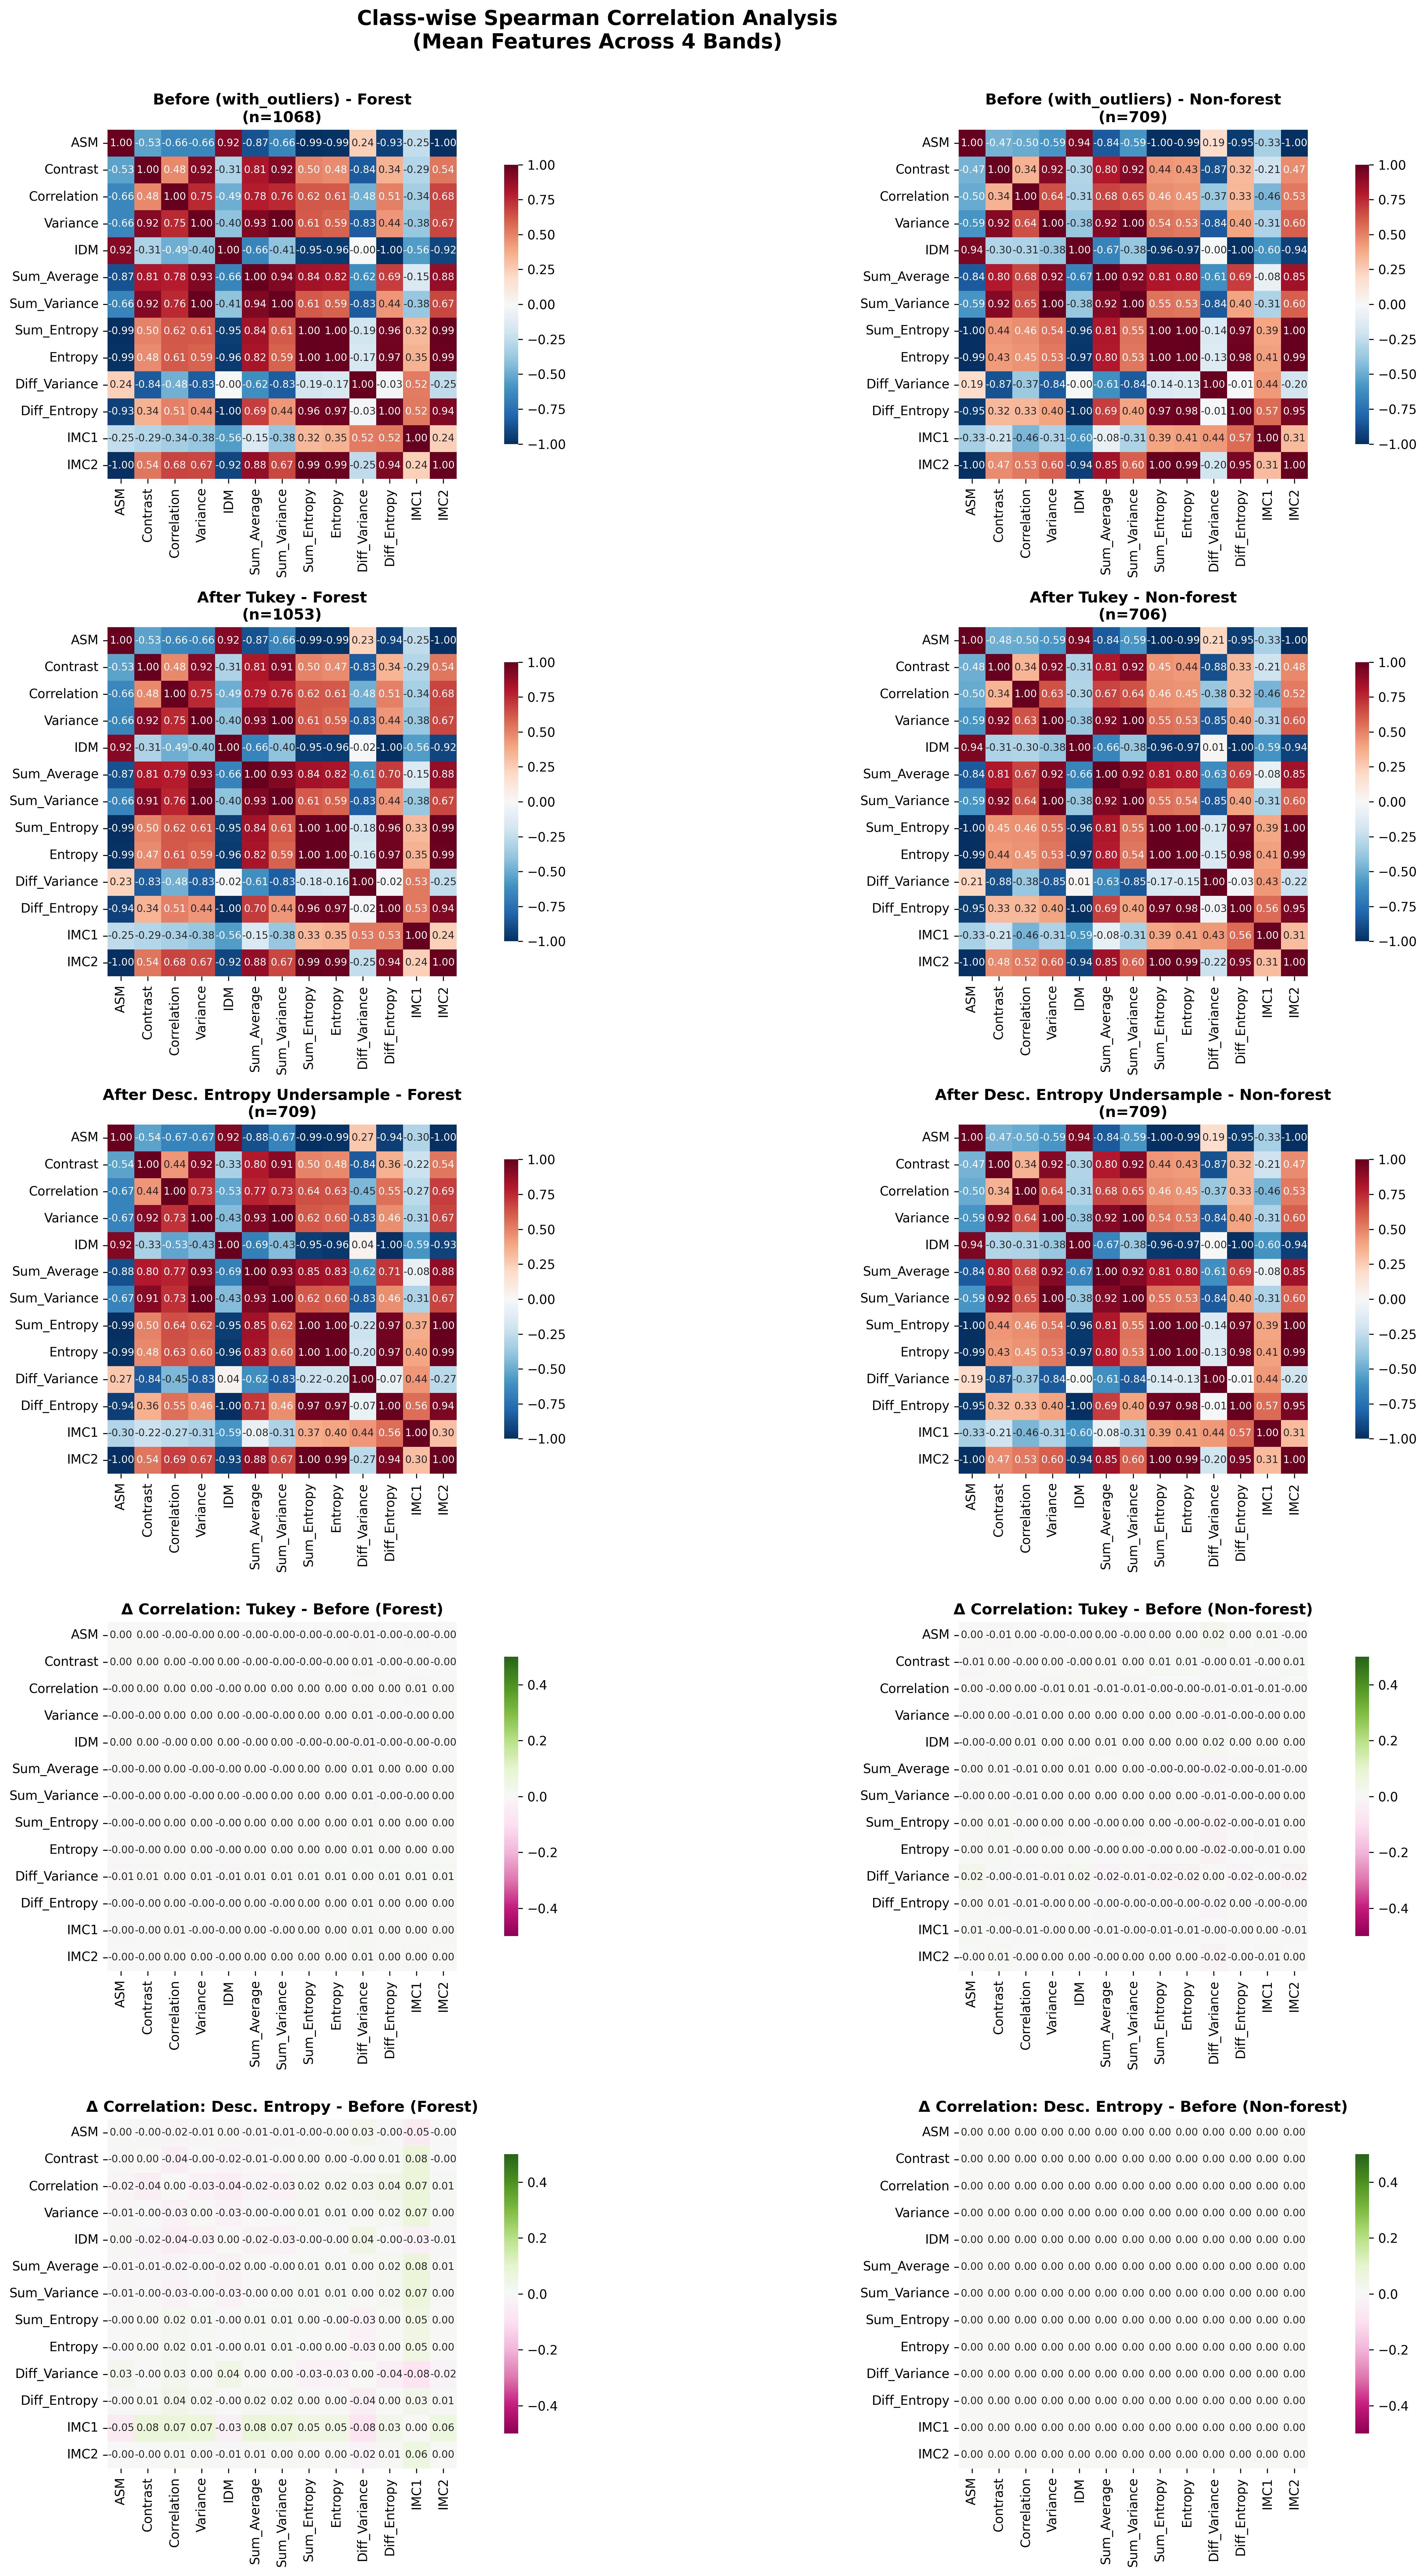

In [22]:
# Prepare correlation matrices and sample counts
corr_matrices = {
    'before_forest': corr_before_forest,
    'before_nonforest': corr_before_nonforest,
    'tukey_forest': corr_tukey_forest,
    'tukey_nonforest': corr_tukey_nonforest,
    'desc_forest': corr_desc_forest,
    'desc_nonforest': corr_desc_nonforest
}

sample_counts = {
    'before_forest': n_forest_before,
    'before_nonforest': n_nonforest_before,
    'tukey_forest': n_forest_tukey,
    'tukey_nonforest': n_nonforest_tukey,
    'desc_forest': n_forest_desc,
    'desc_nonforest': n_nonforest_desc
}

# Plot the 5x2 heatmap grid
diff_tukey_forest, diff_tukey_nonforest, diff_desc_forest, diff_desc_nonforest = plot_correlation_heatmaps_5x2(corr_matrices, sample_counts, dpi=300)

## Summary Statistics

In [17]:
def summarize_correlation_changes(corr_before, corr_after, name):
    """
    Summarize changes in correlation between before and after.
    """
    diff = corr_after - corr_before
    
    # Get upper triangle (excluding diagonal)
    mask = np.triu(np.ones_like(diff, dtype=bool), k=1)
    diff_values = diff.values[mask]
    
    print(f"\n=== {name} ===")
    print(f"Mean absolute change: {np.mean(np.abs(diff_values)):.4f}")
    print(f"Max increase: {np.max(diff_values):.4f}")
    print(f"Max decrease: {np.min(diff_values):.4f}")
    print(f"Std of changes: {np.std(diff_values):.4f}")
    
    # Find top 3 largest absolute changes
    flat_diff = diff.abs().unstack()
    flat_diff = flat_diff[flat_diff.index.get_level_values(0) < flat_diff.index.get_level_values(1)]
    top_changes = flat_diff.nlargest(3)
    print(f"\nTop 3 largest absolute changes:")
    for (f1, f2), val in top_changes.items():
        original_val = diff.loc[f1, f2]
        print(f"  {f1} ↔ {f2}: {original_val:+.4f}")


# Summarize changes
print("\n" + "="*60)
print("CORRELATION CHANGE SUMMARY")
print("="*60)

summarize_correlation_changes(corr_before_forest, corr_tukey_forest, "Tukey vs Before (Forest)")
summarize_correlation_changes(corr_before_nonforest, corr_tukey_nonforest, "Tukey vs Before (Non-forest)")
summarize_correlation_changes(corr_before_forest, corr_desc_forest, "Desc. Entropy Undersample vs Before (Forest)")
summarize_correlation_changes(corr_before_nonforest, corr_desc_nonforest, "Desc. Entropy Undersample vs Before (Non-forest)")


CORRELATION CHANGE SUMMARY

=== Tukey vs Before (Forest) ===
Mean absolute change: 0.0022
Max increase: 0.0104
Max decrease: -0.0105
Std of changes: 0.0034

Top 3 largest absolute changes:
  Diff_Variance ↔ IDM: -0.0105
  Diff_Entropy ↔ Diff_Variance: +0.0104
  Diff_Variance ↔ IMC1: +0.0092

=== Tukey vs Before (Non-forest) ===
Mean absolute change: 0.0051
Max increase: 0.0242
Max decrease: -0.0226
Std of changes: 0.0075

Top 3 largest absolute changes:
  ASM ↔ Diff_Variance: +0.0242
  Diff_Variance ↔ Sum_Entropy: -0.0226
  Diff_Variance ↔ IMC2: -0.0225

=== Desc. Entropy Undersample vs Before (Forest) ===
Mean absolute change: 0.0199
Max increase: 0.0756
Max decrease: -0.0750
Std of changes: 0.0288

Top 3 largest absolute changes:
  IMC1 ↔ Sum_Average: +0.0756
  Contrast ↔ IMC1: +0.0751
  Diff_Variance ↔ IMC1: -0.0750

=== Desc. Entropy Undersample vs Before (Non-forest) ===
Mean absolute change: 0.0000
Max increase: 0.0000
Max decrease: 0.0000
Std of changes: 0.0000

Top 3 largest a

## Export Correlation Matrices (Optional)

In [ ]:
# Optionally save correlation matrices to CSV
import os

output_dir = 'correlation_analysis_results'
os.makedirs(output_dir, exist_ok=True)

corr_before_forest.to_csv(f'{output_dir}/spearman_before_forest.csv')
corr_before_nonforest.to_csv(f'{output_dir}/spearman_before_nonforest.csv')
corr_tukey_forest.to_csv(f'{output_dir}/spearman_tukey_forest.csv')
corr_tukey_nonforest.to_csv(f'{output_dir}/spearman_tukey_nonforest.csv')
corr_desc_forest.to_csv(f'{output_dir}/spearman_desc_entropy_forest.csv')
corr_desc_nonforest.to_csv(f'{output_dir}/spearman_desc_entropy_nonforest.csv')

print(f"Correlation matrices saved to '{output_dir}/' directory.")